In [1]:
#Terceros
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
#Este proyecto
import set_paths
from config.paths import RAW_DATA, PREPRO_DATA, CLEAN_DATA, GROUPED_DATA
from src.preprocessing import drop_dup_null, filter_date
from src.clean import filter_iqr, add_age_column, add_price_m2, group_by_colonia
from src.score import minmax_columns

In [2]:
#load
prep_data_morelos = filter_date(drop_dup_null(RAW_DATA / "properties_morelos.csv"), date_column= "fecha_publi")
#Add price/m2
add_price_m2(prep_data_morelos)
#Drop outliers
clean_data_morelos = filter_iqr(prep_data_morelos, "precio_m2")
#Add age column (days between add publication date and scrap date)
add_age_column(clean_data_morelos)
#save clean
clean_data_morelos[["municipio", "colonia", "precio_m2", "edad_dias"]].to_csv(CLEAN_DATA / "clean_morelos.csv", index = False)
#GROUP_BY_COLONIA
grouped_morelos = group_by_colonia(clean_data_morelos)
    #Filter by minimum number of adds
grouped_morelos = grouped_morelos[grouped_morelos["conteo"] >= 10]
    #Save grouped
grouped_morelos.to_csv(GROUPED_DATA / "grouped_morelos.csv", index= False)

c:\Users\Dense\ALTALTIUM\TAREAS\RANKING_COLONIAS\src\clean.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["edad_dias"] = (fecha - df[column_name]).dt.days


Text(0.5, 0, '$Precio/m^2$')

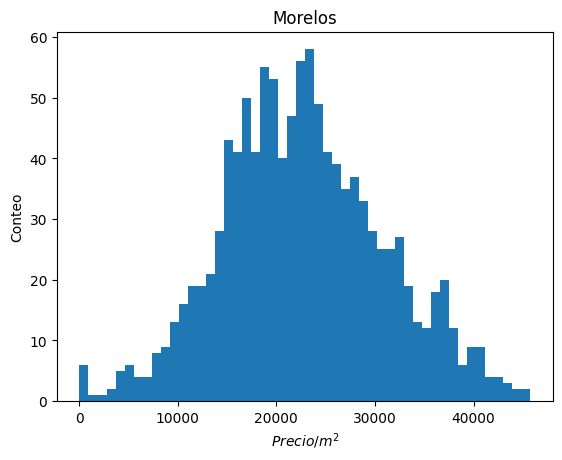

In [3]:
plt.title("Morelos")
n, bins, patches = plt.hist(clean_data_morelos["precio_m2"], bins = 50)
plt.ylabel("Conteo")
plt.xlabel(r"$Precio/m^2$")

In [4]:
normalized = minmax_columns(grouped_morelos, 
                            {"precio_m2_mediana": (0,1), 
                             "precio_m2_cv": (1,0), 
                             "edad_dias_promedio": (1,0)})

## SCORE
$$

score = w_1*(precio\, mediano\, m2) + w_2*\frac{1}{(edad\, anuncios\, promedio)} + w_3*\frac{1}{(coef.\, var)}

$$

In [6]:
pesos = [0.50, 0.25, 0.25]
normalized["score"] = pesos[0]*normalized["precio_m2_mediana"] + pesos[1]*normalized["edad_dias_promedio"] + pesos[2]*normalized["precio_m2_cv"]

In [12]:
#test
normalized[["municipio", "colonia", "score"]].sort_values(by="score", ascending=False).head(10)

,municipio,colonia,score
150,Emiliano Zapata,Fraccionamiento Paraíso Country Club,0.864967
123,Cuernavaca,Reforma,0.781319
166,Emiliano Zapata,Tres de Mayo,0.710020
95,Cuernavaca,Lomas de Cortes,0.695253
39,Cuernavaca,Chapultepec,0.687458
1,Atlatlahucan,Fraccionamiento Lomas de Cocoyoc,0.677248
138,Cuernavaca,Vista Hermosa,0.664317
48,Cuernavaca,Delicias,0.624900
221,Temixco,Fraccionamiento Burgos Bugambilias,0.604332
110,Cuernavaca,Palmira Tingüindín,0.562925
